# Tarea 1 Inteligencia Artificial - Parte 2
#### Magdalena Correa - Martin Melo


Se trabajará con el dataset **Appliances Energy Prediction**,
que contiene mediciones del consumo energético de electrodomésticos, iluminación
y condiciones ambientales de una vivienda, registradas cada 10 minutos. El objetivo
es analizar la evolución temporal del consumo mediante cadenas de Markov y
posteriormente inferir su comportamiento utilizando modelos ocultos de Markov
(HMM). El consumo registrado en la variable Appliances deberá clasificarse en seis
estados: muy bajo, bajo, medio-bajo, medio-alto, alto y muy alto. Para construir las
observaciones del HMM, considere la variable lights y los siguientes índices:

$$I_{\text{temperatura}} = \frac{T_1 + T_2 + T_3}{3}, \qquad I_{\text{humedad}} = \frac{RH_1 + RH_2 + RH_3}{3}$$

## Importaciones

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from hmmlearn.hmm import CategoricalHMM

## Parte a - Definición de los 6 estados de consumo, de las 27 observaciones y separación cronológica:

In [3]:
df = pd.read_csv("Dataset/energydata_complete.csv", parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)

print(df.shape)
print(df["date"].min(), "->", df["date"].max())
print("nulos:", df.isna().sum().sum())
df.head()

(19735, 29)
2016-01-11 17:00:00 -> 2016-05-27 18:00:00
nulos: 0


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


In [4]:
saltos = df["date"].diff().dropna()
print(saltos.value_counts())

date
0 days 00:10:00    19734
Name: count, dtype: int64


### Los 6 estados de consumo

Antes de elegir los cortes se observa cómo se distribuye `Appliances`.

In [5]:
print(df["Appliances"].describe())
print()
print("valores distintos:", df["Appliances"].nunique())
print("los 8 más frecuentes (%):")
print((df["Appliances"].value_counts(normalize=True).head(8) * 100).round(2))

count    19735.000000
mean        97.694958
std        102.524891
min         10.000000
25%         50.000000
50%         60.000000
75%        100.000000
max       1080.000000
Name: Appliances, dtype: float64

valores distintos: 92
los 8 más frecuentes (%):
Appliances
50     22.13
60     16.63
40     10.23
70      7.90
80      6.11
90      5.14
100     4.96
110     3.73
Name: proportion, dtype: float64


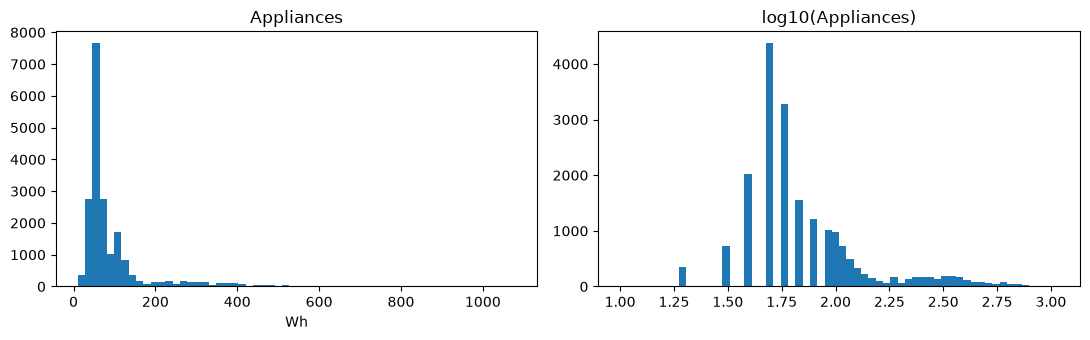

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].hist(df["Appliances"], bins=60)
ax[0].set_title("Appliances")
ax[0].set_xlabel("Wh")
ax[1].hist(np.log10(df["Appliances"]), bins=60)
ax[1].set_title("log10(Appliances)")
plt.tight_layout()
plt.show()

In [10]:
# Lo primero que probé fue cortar por sextiles, pero no se puede
try:
    pd.qcut(df["Appliances"], 6)
except ValueError as e:
    print("Falla:", e)

# Y cortando en 6 intervalos de igual ancho queda casi todo en la primera clase
print()
print(pd.cut(df["Appliances"], 6).value_counts().sort_index())

Falla: Bin edges must be unique: Index([10.0, 50.0, 50.0, 60.0, 80.0, 120.0, 1080.0], dtype='float64', name='Appliances').
You can drop duplicate edges by setting the 'duplicates' kwarg

Appliances
(8.93, 188.333]       17675
(188.333, 366.667]     1310
(366.667, 545.0]        520
(545.0, 723.333]        184
(723.333, 901.667]       43
(901.667, 1080.0]         3
Name: count, dtype: int64


Como la variable está muy cargada hacia valores bajos, se termino usando umbrales fijos
apoyados en los percentiles y en que los valores son múltiplos de 10.

In [8]:
estados = ["muy bajo", "bajo", "medio-bajo", "medio-alto", "alto", "muy alto"]
cortes = [0, 40, 50, 70, 110, 200, np.inf]

df["estado_nombre"] = pd.cut(df["Appliances"], bins=cortes, labels=estados, include_lowest=True)
df["estado"] = df["estado_nombre"].cat.codes

resumen = df.groupby("estado_nombre", observed=False)["Appliances"].agg(["count", "min", "max"])
resumen["%"] = (resumen["count"] / len(df) * 100).round(2)
resumen

,count,min,max,%
estado_nombre,,,,
muy bajo,3094,10,40,15.68
bajo,4368,50,50,22.13
medio-bajo,4842,60,70,24.54
medio-alto,3934,80,110,19.93
alto,1581,120,200,8.01
muy alto,1916,210,1080,9.71


La distribución de Appliances es fuertemente asimétrica (coeficiente 3,39; media 97,69 frente a mediana 60) y solo seis valores concentran el 68,14% de las mediciones. Por eso la discretización por cuantiles falla. Los percentiles 16,7 y 33,3 caen ambos en 50 Wh, así que dos cortes coinciden y no se pueden formar seis intervalos. Los intervalos de ancho constante tampoco sirven, porque dejan el 89,56% de los datos en el primer bin y solo 3 registros en el último, insuficientes para estimar una fila de la matriz de transición. Se optó por los umbrales fijos [0, 40, 50, 70, 110, 200, inf].

### Los índices ambientales y lights

$$I_{\text{temperatura}} = \frac{T_1 + T_2 + T_3}{3}, \qquad I_{\text{humedad}} = \frac{RH_1 + RH_2 + RH_3}{3}$$

In [11]:
df["I_temp"] = df[["T1", "T2", "T3"]].mean(axis=1)
df["I_hum"] = df[["RH_1", "RH_2", "RH_3"]].mean(axis=1)

print(df[["I_temp", "I_hum"]].describe().round(2))
print()
print("lights (%):")
print((df["lights"].value_counts(normalize=True).sort_index() * 100).round(2))

         I_temp     I_hum
count  19735.00  19735.00
mean      21.43     39.97
std        1.81      3.47
min       16.70     26.55
25%       20.26     37.41
50%       21.20     39.58
75%       22.41     42.46
max       27.42     51.89

lights (%):
lights
0     77.28
10    11.21
20     8.23
30     2.83
40     0.39
50     0.05
60     0.01
70     0.01
Name: proportion, dtype: float64


### Separación cronológica

Corte en el 80% de los registros. Se realiza antes de calcular los terciles de los índices, para que los umbrales salgan solo del tramo de entrenamiento y no use información del futuro.

In [12]:
n_corte = int(len(df) * 0.8)
es_train = df.index < n_corte

print("train:", es_train.sum(), "|", df.loc[es_train, "date"].min(), "->", df.loc[es_train, "date"].max())
print("test: ", (~es_train).sum(), "|", df.loc[~es_train, "date"].min(), "->", df.loc[~es_train, "date"].max())

train: 15788 | 2016-01-11 17:00:00 -> 2016-04-30 08:10:00
test:  3947 | 2016-04-30 08:20:00 -> 2016-05-27 18:00:00


In [13]:
# Terciles calculados solo con train
t1, t2 = df.loc[es_train, "I_temp"].quantile([1/3, 2/3])
h1, h2 = df.loc[es_train, "I_hum"].quantile([1/3, 2/3])
print(f"temperatura: baja <= {t1:.2f} < media <= {t2:.2f} < alta")
print(f"humedad:     baja <= {h1:.2f} < media <= {h2:.2f} < alta")

df["n_temp"] = np.where(df["I_temp"] <= t1, 0, np.where(df["I_temp"] <= t2, 1, 2))
df["n_hum"] = np.where(df["I_hum"] <= h1, 0, np.where(df["I_hum"] <= h2, 1, 2))

# lights: apagada / consumo bajo / consumo alto
df["n_lights"] = np.where(df["lights"] == 0, 0, np.where(df["lights"] <= 20, 1, 2))

for col in ["n_temp", "n_hum", "n_lights"]:
    print(col, (df[col].value_counts(normalize=True).sort_index() * 100).round(2).to_dict())

temperatura: baja <= 20.35 < media <= 21.36 < alta
humedad:     baja <= 38.33 < media <= 41.39 < alta
n_temp {0: 26.75, 1: 27.5, 2: 45.75}
n_hum {0: 35.0, 1: 31.56, 2: 33.44}
n_lights {0: 77.28, 1: 19.44, 2: 3.28}


Los terciles de temperatura y humedad se calcularon únicamente sobre el tramo de entrenamiento, para evitar que información del periodo de evaluación influyera en los umbrales. Esta decisión tiene un costo visible, como el tramo de evaluación corresponde a mayo y la temperatura media sube 2,35 °C respecto de abril, el 96,07% de sus registros cae en el nivel alto. En cuanto a la cobertura del alfabeto, las 27 combinaciones posibles (3×3×3) aparecen en los datos, y ninguna observación del conjunto de evaluación está ausente del de entrenamiento, de modo que el modelo no enfrentará observaciones sin frecuencia estimada. Nueve de esas combinaciones representan menos del 1% cada una. La iluminación permanece apagada el 77,28% del tiempo, y el 96,72% acumulado se alcanza en los 20 Wh.

### Las 27 observaciones

Se codifico la tripleta en un solo número: $o = 9 \cdot temp + 3 \cdot hum + lights$, entre 0 y 26.

In [14]:
df["obs"] = 9 * df["n_temp"] + 3 * df["n_hum"] + df["n_lights"]

print("observaciones distintas:", df["obs"].nunique(), "de 27")
print("nunca observadas:", sorted(set(range(27)) - set(df["obs"].unique())))

# Tabla de las 27 combinaciones para tenerla de referencia
nombres_t = ["temp baja", "temp media", "temp alta"]
nombres_h = ["hum baja", "hum media", "hum alta"]
nombres_l = ["apagada", "luz baja", "luz alta"]

catalogo = pd.DataFrame([(o, nombres_t[o // 9], nombres_h[(o % 9) // 3], nombres_l[o % 3])
                         for o in range(27)],
                        columns=["codigo", "temperatura", "humedad", "lights"])
catalogo["frecuencia"] = catalogo["codigo"].map(df["obs"].value_counts())
catalogo

observaciones distintas: 27 de 27
nunca observadas: []


,codigo,temperatura,humedad,lights,frecuencia
0,0,temp baja,hum baja,apagada,1655
1,1,temp baja,hum baja,luz baja,389
2,2,temp baja,hum baja,luz alta,40
3,3,temp baja,hum media,apagada,1282
4,4,temp baja,hum media,luz baja,348
5,5,temp baja,hum media,luz alta,57
6,6,temp baja,hum alta,apagada,1166
7,7,temp baja,hum alta,luz baja,273
8,8,temp baja,hum alta,luz alta,69
9,9,temp media,hum baja,apagada,1481


In [15]:
cols = ["date", "Appliances", "estado", "estado_nombre", "obs"]
train = df.loc[es_train, cols].reset_index(drop=True)
test = df.loc[~es_train, cols].reset_index(drop=True)

train["dia"] = train["date"].dt.date
test["dia"] = test["date"].dt.date

print("no hay solapamiento:", train["date"].max() < test["date"].min())
print("obs de test que no están en train:", sorted(set(test["obs"]) - set(train["obs"])))
print()
print(pd.DataFrame({
    "train %": train["estado_nombre"].value_counts(normalize=True).reindex(estados) * 100,
    "test %": test["estado_nombre"].value_counts(normalize=True).reindex(estados) * 100,
}).round(2))

no hay solapamiento: True
obs de test que no están en train: []

               train %  test %
estado_nombre                 
muy bajo         18.29    5.22
bajo             22.05   22.45
medio-bajo       22.62   32.20
medio-alto       18.98   23.76
alto              7.98    8.13
muy alto         10.08    8.23


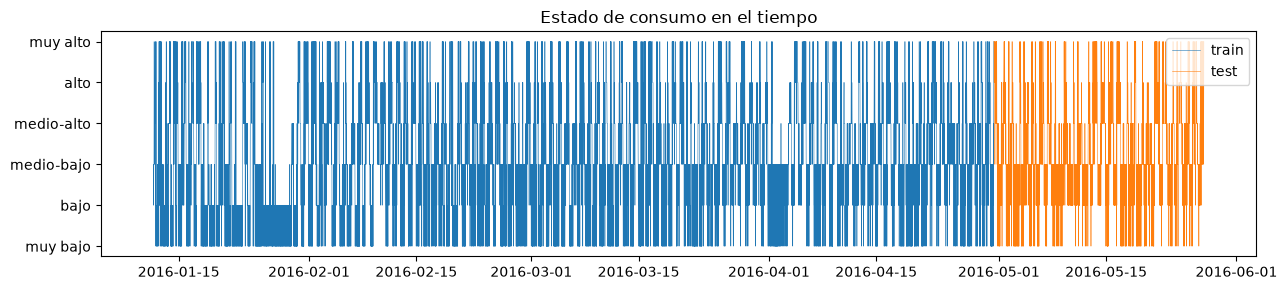

In [16]:
fig, ax = plt.subplots(figsize=(13, 3))
ax.plot(train["date"], train["estado"], lw=0.4, label="train")
ax.plot(test["date"], test["estado"], lw=0.4, label="test")
ax.set_yticks(range(6))
ax.set_yticklabels(estados)
ax.legend()
ax.set_title("Estado de consumo en el tiempo")
plt.tight_layout()
plt.show()

El muestreo del dataset es regular cada 10 minutos, sin vacíos ni registros duplicados. La división cronológica 80/20, en cambio, introduce un desplazamiento estacional entre ambos tramos, como el conjunto de evaluación corresponde a mayo, la temperatura media pasa de 21,70 °C en abril a 24,05 °C, y el nivel de temperatura "alta" salta de 33,17% en entrenamiento a 96,07% en evaluación. El consumo medio mensual se mantiene estable a lo largo de todo el periodo, con variaciones menores al 5%, pero la distribución de los estados sí cambia a "muy bajo" y cae de 18,29% a 5,22%, una diferencia de 13,07 puntos porcentuales que equivale a una reducción del 71%, mientras "medio-bajo" sube 9,58 puntos.


# (b) Las dos cadenas de Markov

Construir dos cadenas de Markov: una considerando todos los registros
como una secuencia continua y otra considerando cada día como una
secuencia independiente. Estimar mediante conteos las matrices de
transición correspondientes. Para el modelo continuo, utilizar su distribución
estacionaria como distribución inicial; para el modelo diario, estimar la
distribución inicial a partir del primer estado de cada jornada.
